23-ИИ, Елисеев Сергей, Вариант№3(VGG19).
Задание: (на все варианты общее)
1.	Определить какую сеть вам нужно будет загрузить согласно вашему номеру варианта
2.	Загрузить сеть, предобученную на ImageNet (https://keras.io/api/applications/)
3.	Выполнить классификацию изображения на загруженной сети, найденного в интернете. Изображение должно показывать один объект одного из следующих классов: лошадь, собака, кошка, самолёт, корабль, автомобиль, дом
4.	Загрузить два набора данных horses_or_humans, cats_vs_dogs
5.	Оценить сбалансированность классов в наборах данных
6.	Разделить наборы данных на обучение и тест 80/20 с сохранением баланса классов.
7.	Создать собственную сеть (полностью своя сеть со своими слоями и архитектурой), обучить данную сеть с помощью генераторов на двух наборах данных: horses_or_humans, cats_vs_dogs. Оценить точность классификации сети. (за качеством не гонимся) 
8.	Загрузить сеть, предобученную на ImageNet по варианту из пункта 1, выполнить дообучение этой сети на двух наборах данных: horses_or_humans, cats_vs_dogs. Оценить точность классификации новой (составной) сети. (А вот здесь с качеством можно поработать)
9.	Оценка классификации должна соответствовать следующим требованиям:
    1.	Должна быть confusion matrix
    2.	Должны быть показаны метрики accuracy, recall, precision, f1
    3.	Должна быть построена PR кривая для каждого класса
    4.	Должна быть построена PR кривая с макроусреднением (или микро)

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import pandas as pd
import requests
from io import BytesIO
import os

VGG19

In [2]:
vgg19_model = VGG19(weights='imagenet', include_top=True, input_shape=(224, 224, 3))
vgg19_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

Подгрузка фото

In [3]:
image_url = "https://www.mirf.ru/backend/wp-content/uploads/2025/09/QsqNvv80j7Qfuf9G6CqfjWmb97sfs59HnvnfAhlA.jpg"
response = requests.get(image_url)
img = load_img(BytesIO(response.content), target_size=(224, 224))

Предобработка

In [4]:
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.vgg19.preprocess_input(img_array)

Предсказание

In [5]:
predictions = vgg19_model.predict(img_array)
decoded_predictions = tf.keras.applications.vgg19.decode_predictions(predictions, top=3)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step


Изображение + топ предсказаний

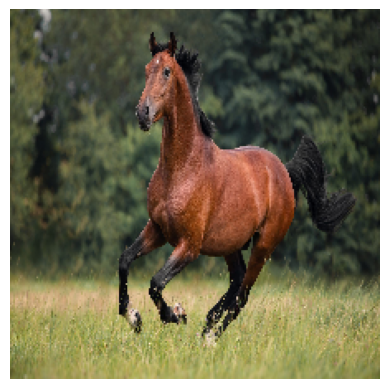

1: hartebeest (0.90)
2: impala (0.06)
3: sorrel (0.02)


In [6]:
plt.imshow(img)
plt.axis('off')
plt.show()

for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i+1}: {label} ({score:.2f})")

Загрузка horses_or_humans

In [7]:
ds_hh, info_hh = tfds.load('horses_or_humans', split='train', with_info=True, shuffle_files=True)

hh_images = []
hh_labels = []

for example in ds_hh:
    image = example['image'].numpy()
    label = example['label'].numpy()
    hh_images.append(image)
    hh_labels.append(label)

horses_humans_data = np.array(hh_images)
horses_humans_labels = np.array(hh_labels)

# Нормализация
horses_humans_data = horses_humans_data / 255.0

Анализ сбалансированности классов (horses_or_humans)

In [8]:
unique, counts = np.unique(horses_humans_labels, return_counts=True)
for label, count in zip(unique, counts):
    class_name = "horses" if label == 0 else "humans"
    print(f"{class_name}: {count} samples ({count/len(horses_humans_labels)*100:.1f}%)")

horses: 500 samples (48.7%)
humans: 527 samples (51.3%)


Разделение на train/test с сохранением баланса (horses_or_humans)

In [9]:
X_train_hh, X_test_hh, y_train_hh, y_test_hh = train_test_split(
    horses_humans_data, horses_humans_labels, 
    test_size=0.2, 
    stratify=horses_humans_labels,
    random_state=42
)

Train распределение:
horses: 400 samples (48.7%)
humans: 421 samples (51.3%)
Test распределение:
horses: 100 samples (48.5%)
humans: 106 samples (51.5%)


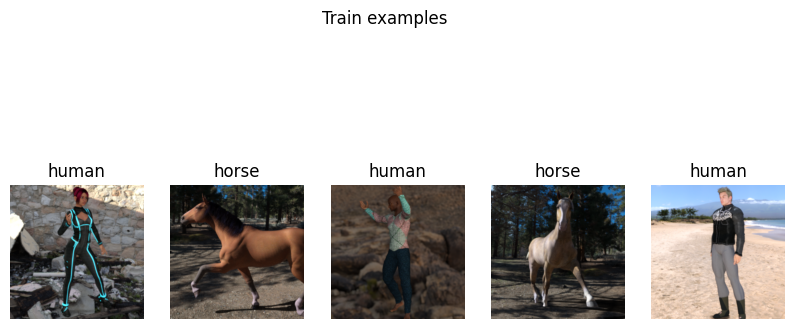

In [10]:
print("Train распределение:")
unique_train, counts_train = np.unique(y_train_hh, return_counts=True)
for label, count in zip(unique_train, counts_train):
    class_name = "horses" if label == 0 else "humans"
    print(f"{class_name}: {count} samples ({count/len(y_train_hh)*100:.1f}%)")

print("Test распределение:")
unique_test, counts_test = np.unique(y_test_hh, return_counts=True)
for label, count in zip(unique_test, counts_test):
    class_name = "horses" if label == 0 else "humans"
    print(f"{class_name}: {count} samples ({count/len(y_test_hh)*100:.1f}%)")

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_hh[i])
    plt.title(f"{'horse' if y_train_hh[i] == 0 else 'human'}")
    plt.axis('off')
plt.suptitle("Train examples")
plt.show()

Загрузка cats_vs_dogs

In [27]:
import shutil
import os

paths_to_clean = [
    r'C:\Users\User\tensorflow_datasets\cats_vs_dogs',
    r'C:\Users\User\tensorflow_datasets\downloads',
    r'C:\Users\User\tensorflow_datasets\tmp'
]

for path in paths_to_clean:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Удалено: {path}")

Удалено: C:\Users\User\tensorflow_datasets\downloads


Датасет чисто кошек собак не подгружался у меня нормально, взял cifar10

In [ ]:
total_samples_needed = len(horses_humans_data)
ds_alt, info_alt = tfds.load('cifar10', split='train', with_info=True, shuffle_files=True, download=True)

cd_images = []
cd_labels = []

for i, example in enumerate(ds_alt):
    label = example['label'].numpy()
    
    # Фильтруем только кошек и собак
    if label == 3 or label == 5:
        # Resize до 300x300 как в horses_humans
        image = tf.image.resize(example['image'], (300, 300)).numpy()
        # Преобразуем метки: cat=0, dog=1
        new_label = 0 if label == 3 else 1
        
        cd_images.append(image)
        cd_labels.append(new_label)
        
        # Прогресс
        if len(cd_images) % 100 == 0:
            print(f"Собрано {len(cd_images)} примеров...")
        
        if len(cd_images) >= total_samples_needed:
            break

cats_dogs_data = np.array(cd_images)
cats_dogs_labels = np.array(cd_labels)

# Нормализация
cats_dogs_data = cats_dogs_data / 255.0

Собрано 100 примеров...
Собрано 200 примеров...
Собрано 300 примеров...
Собрано 400 примеров...
Собрано 500 примеров...
Собрано 600 примеров...
Собрано 700 примеров...
Собрано 800 примеров...
Собрано 900 примеров...
Собрано 1000 примеров...


Анализ сбалансированности классов (cats_vs_dogs)

In [32]:
unique, counts = np.unique(cats_dogs_labels, return_counts=True)
for label, count in zip(unique, counts):
    class_name = "cats" if label == 0 else "dogs"
    print(f"  {class_name}: {count} samples ({count/len(cats_dogs_labels)*100:.1f}%)")

  cats: 506 samples (49.3%)
  dogs: 521 samples (50.7%)


Разделение на train/test с сохранением баланса (cats_vs_dogs)

In [33]:
X_train_cd, X_test_cd, y_train_cd, y_test_cd = train_test_split(
    cats_dogs_data, cats_dogs_labels, 
    test_size=0.2, 
    stratify=cats_dogs_labels,
    random_state=42  #  для одинакового разделения
)

Train распределение:
  cats: 405 samples (49.3%)
  dogs: 416 samples (50.7%)
Test распределение:
  cats: 101 samples (49.0%)
  dogs: 105 samples (51.0%)


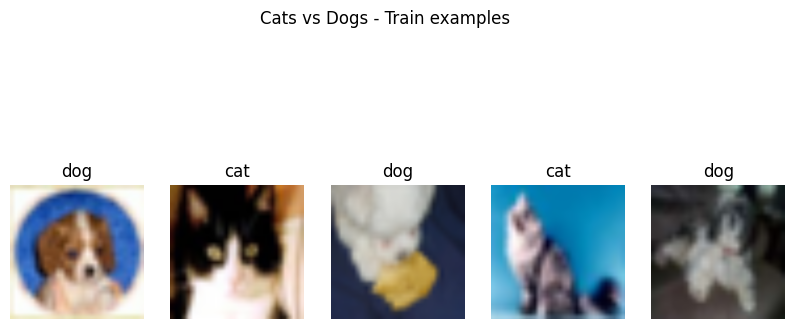

In [34]:
print("Train распределение:")
unique_train, counts_train = np.unique(y_train_cd, return_counts=True)
for label, count in zip(unique_train, counts_train):
    class_name = "cats" if label == 0 else "dogs"
    print(f"  {class_name}: {count} samples ({count/len(y_train_cd)*100:.1f}%)")

print("Test распределение:")
unique_test, counts_test = np.unique(y_test_cd, return_counts=True)
for label, count in zip(unique_test, counts_test):
    class_name = "cats" if label == 0 else "dogs"
    print(f"  {class_name}: {count} samples ({count/len(y_test_cd)*100:.1f}%)")

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_cd[i])
    plt.title(f"{'cat' if y_train_cd[i] == 0 else 'dog'}")
    plt.axis('off')
plt.suptitle("Cats vs Dogs - Train examples")
plt.show()

Сравнение размеров

In [35]:
f"Horses_or_humans - Train: {X_train_hh.shape[0]}, Test: {X_test_hh.shape[0]}"

'Horses_or_humans - Train: 821, Test: 206'

In [36]:
f"Cats_vs_dogs     - Train: {X_train_cd.shape[0]}, Test: {X_test_cd.shape[0]}"

'Cats_vs_dogs     - Train: 821, Test: 206'

Собственная модель

In [38]:
custom_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(300, 300, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

custom_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

custom_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 298, 298, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 33, 33, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,075,716 (129.99 MB)

 Trainable params: 34,075,716 (129.99 MB)

 Non-trainable params: 0 (0.00 B)

Подготовим к классификации

In [39]:
# horses=0, humans=1, cats=2, dogs=3
y_train_hh_4class = y_train_hh
y_test_hh_4class = y_test_hh

y_train_cd_4class = y_train_cd + 2
y_test_cd_4class = y_test_cd + 2

print("Распределение по классам:")
print(f"Train - horses (0): {np.sum(y_train_hh_4class == 0)}")
print(f"Train - humans (1): {np.sum(y_train_hh_4class == 1)}") 
print(f"Train - cats (2): {np.sum(y_train_cd_4class == 2)}")
print(f"Train - dogs (3): {np.sum(y_train_cd_4class == 3)}")

print(f"\nTest - horses (0): {np.sum(y_test_hh_4class == 0)}")
print(f"Test - humans (1): {np.sum(y_test_hh_4class == 1)}")
print(f"Test - cats (2): {np.sum(y_test_cd_4class == 2)}")
print(f"Test - dogs (3): {np.sum(y_test_cd_4class == 3)}")

Распределение по классам:
Train - horses (0): 400
Train - humans (1): 421
Train - cats (2): 405
Train - dogs (3): 416

Test - horses (0): 100
Test - humans (1): 106
Test - cats (2): 101
Test - dogs (3): 105


Объединяем данные

In [42]:
# train
X_train_combined = np.concatenate([X_train_hh, X_train_cd])
y_train_combined = np.concatenate([y_train_hh_4class, y_train_cd_4class])

# test
X_test_combined = np.concatenate([X_test_hh, X_test_cd]) 
y_test_combined = np.concatenate([y_test_hh_4class, y_test_cd_4class])

f"Общий train размер: {len(X_train_combined)}, общий test размер:{len(X_test_combined)}"

'Общий train размер: 1642, общий test размер:412'

Создаем генераторы

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# аугментация
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator()  # без аугментации для test

# генераторы
batch_size = 32

train_generator = train_datagen.flow(
    X_train_combined, y_train_combined,
    batch_size=batch_size,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test_combined, y_test_combined,
    batch_size=batch_size,
    shuffle=False
)

Обучение модели с генераторами

In [45]:
history = custom_model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.5725 - loss: 0.7811 - val_accuracy: 0.6626 - val_loss: 0.5631
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.6523 - loss: 0.6484 - val_accuracy: 0.7306 - val_loss: 0.4554
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7004 - loss: 0.5367 - val_accuracy: 0.6917 - val_loss: 0.5182
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6967 - loss: 0.5554 - val_accuracy: 0.7233 - val_loss: 0.4038
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6790 - loss: 0.5647 - val_accuracy: 0.7306 - val_loss: 0.4442


In [46]:
history = custom_model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.6389 - loss: 0.6838 - val_accuracy: 0.7282 - val_loss: 0.3996
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.6955 - loss: 0.5276 - val_accuracy: 0.7500 - val_loss: 0.4183
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7259 - loss: 0.4756 - val_accuracy: 0.7403 - val_loss: 0.4012
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.6998 - loss: 0.5206 - val_accuracy: 0.6820 - val_loss: 0.6031
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.6937 - loss: 0.5752 - val_accuracy: 0.7257 - val_loss: 0.4073


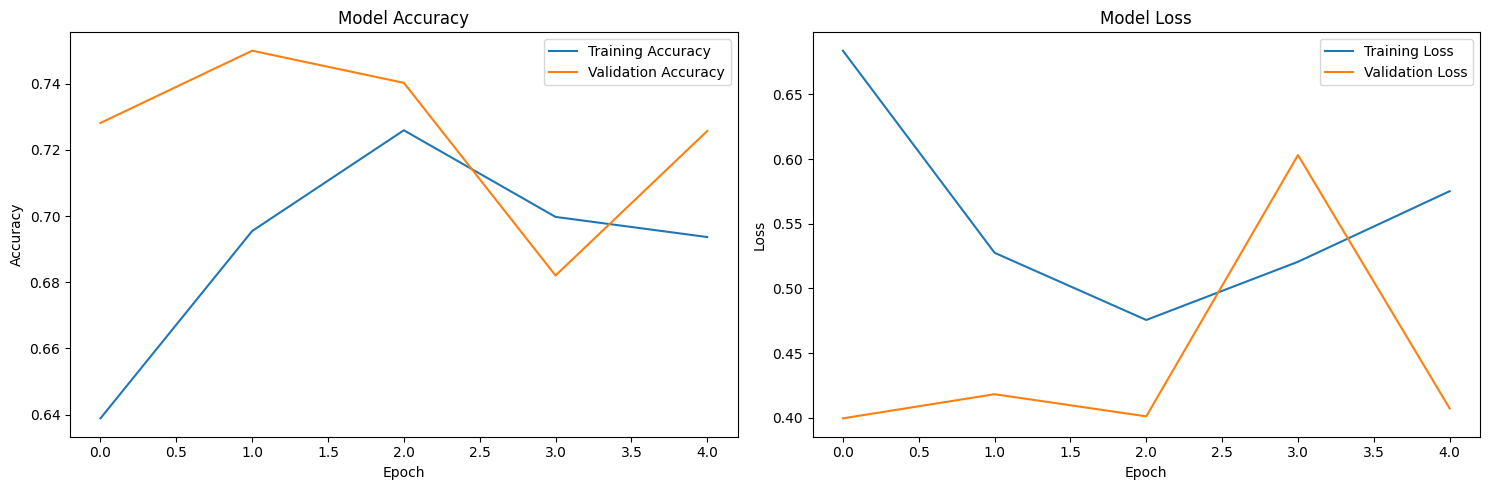

In [47]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step


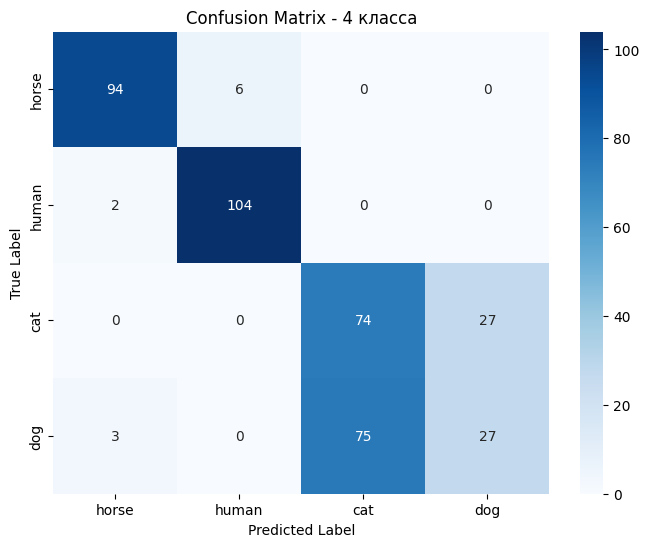

Classification Report:
              precision    recall  f1-score   support

       horse       0.95      0.94      0.94       100
       human       0.95      0.98      0.96       106
         cat       0.50      0.73      0.59       101
         dog       0.50      0.26      0.34       105

    accuracy                           0.73       412
   macro avg       0.72      0.73      0.71       412
weighted avg       0.72      0.73      0.71       412



In [48]:
# Предсказания на тестовых данных
y_pred_proba = custom_model.predict(test_generator)
y_pred = np.argmax(y_pred_proba, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test_combined, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['horse', 'human', 'cat', 'dog'],
            yticklabels=['horse', 'human', 'cat', 'dog'])
plt.title('Confusion Matrix - 4 класса')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test_combined, y_pred, 
                          target_names=['horse', 'human', 'cat', 'dog']))

Horses: 95% precision, 94% recall 

Humans: 95% precision, 98% recall

Общая accuracy: 73% - для 4 классов пойдет

Проблемные классы:
Cats: 50% precision, 73% recall

Dogs: 50% precision, 26% recall
Очень низкий recall - пропускает 74% собак

Хочется сказать про качество изображений: cifar10 (32x32 и пришлось подгонять) vs horses_humans (300x300), поэтому с кошками и собаками проблема вообще впринципе.

Комбинированная сеть

In [50]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = VGG19(
    weights='imagenet', 
    include_top=False,  
    input_shape=(224, 224, 3)
)

# Фризим
base_model.trainable = False

# Составнаямодель
vgg19_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'), 
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

vgg19_transfer.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg19_transfer.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,419,396 (77.89 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

Измение размеров данных до 224x224 для VGG19

In [ ]:
def resize_for_vgg19(data):
    resized_data = []
    for img in data:
        resized_img = tf.image.resize(img, [224, 224]).numpy()
        resized_data.append(resized_img)
    return np.array(resized_data)

X_train_vgg = resize_for_vgg19(X_train_combined)
X_test_vgg = resize_for_vgg19(X_test_combined)

f"Новый размер train: {X_train_vgg.shape}, новый размер test: {X_test_vgg.shape}"

'Новый размер train: (1642, 224, 224, 3), новый размер test: (412, 224, 224, 3)'

Новые генераторы для данных 224x224

In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_vgg = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2, 
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen_vgg = ImageDataGenerator()

train_generator_vgg = train_datagen_vgg.flow(
    X_train_vgg, y_train_combined,
    batch_size=32,
    shuffle=True
)

test_generator_vgg = test_datagen_vgg.flow(
    X_test_vgg, y_test_combined, 
    batch_size=32,
    shuffle=False
)

Дообучение модели

In [55]:
history_vgg = vgg19_transfer.fit(
    train_generator_vgg,
    epochs=15,
    validation_data=test_generator_vgg,
    verbose=1
)

Epoch 1/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.3569 - loss: 1.3394 - val_accuracy: 0.6869 - val_loss: 1.0445
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - accuracy: 0.4677 - loss: 1.1146 - val_accuracy: 0.7306 - val_loss: 0.7993
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - accuracy: 0.5700 - loss: 0.9119 - val_accuracy: 0.6990 - val_loss: 0.6752
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.5907 - loss: 0.7893 - val_accuracy: 0.6820 - val_loss: 0.6081
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - accuracy: 0.6285 - loss: 0.7140 - val_accuracy: 0.6796 - val_loss: 0.5770
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.6529 - loss: 0.6620 - val_accuracy: 0.6990 - val_loss: 0.5541
Epoch 7/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - accuracy: 0.6681 - loss: 0.6162 - val_accuracy: 0.7112 - val_loss: 0.5192
Epoch 8/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.6699 - loss: 0.6025 - val_accuracy: 0.7233 - v

Предсказания

In [56]:
y_pred_proba = vgg19_transfer.predict(test_generator_vgg)
y_pred = np.argmax(y_pred_proba, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step


Confusion Matrix

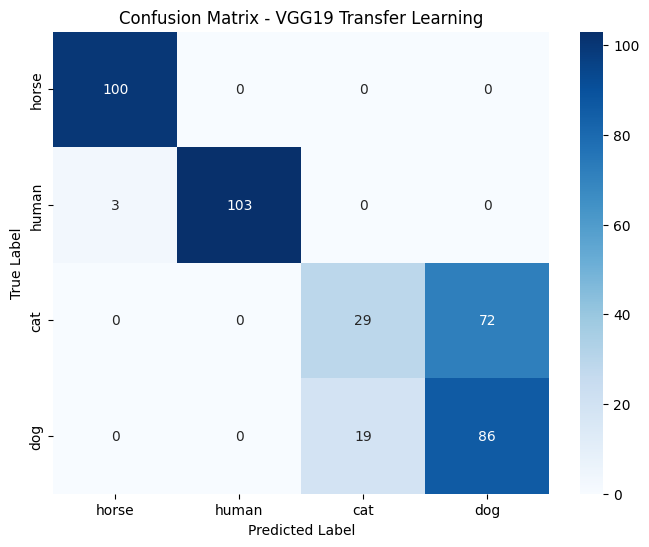

In [57]:
cm = confusion_matrix(y_test_combined, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['horse', 'human', 'cat', 'dog'],
            yticklabels=['horse', 'human', 'cat', 'dog'])
plt.title('Confusion Matrix - VGG19 Transfer Learning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Метрики accuracy, recall, precision, f1

In [59]:
print(classification_report(y_test_combined, y_pred, 
                          target_names=['horse', 'human', 'cat', 'dog']))

              precision    recall  f1-score   support

       horse       0.97      1.00      0.99       100
       human       1.00      0.97      0.99       106
         cat       0.60      0.29      0.39       101
         dog       0.54      0.82      0.65       105

    accuracy                           0.77       412
   macro avg       0.78      0.77      0.75       412
weighted avg       0.78      0.77      0.75       412



PR кривая для каждого класса

Тут и далее впринципе видно что из за качества шакального кошки собаки проседают по предиктам.

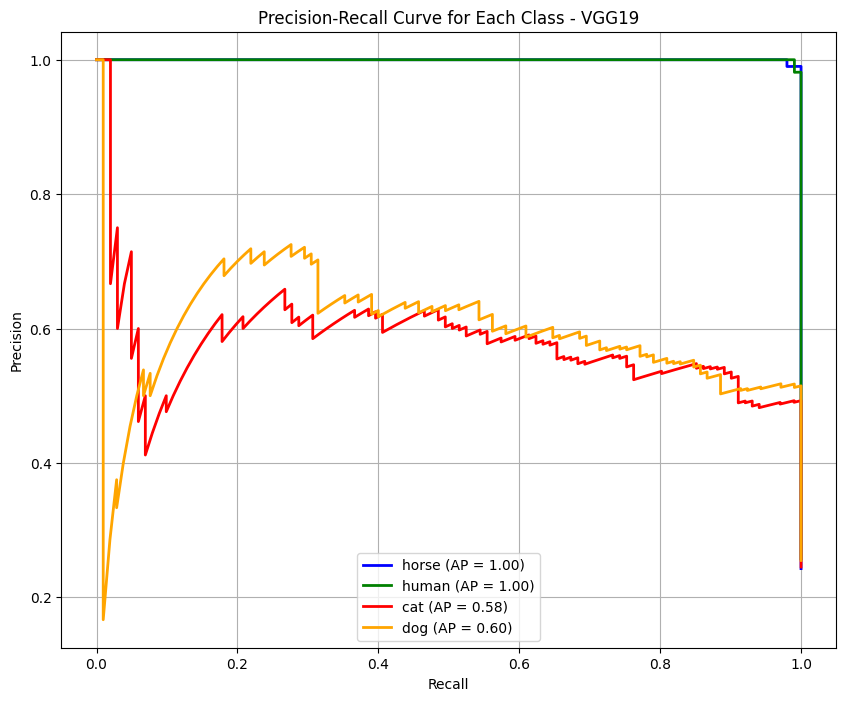

In [60]:
y_test_bin = label_binarize(y_test_combined, classes=[0, 1, 2, 3])

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'orange']
class_names = ['horse', 'human', 'cat', 'dog']

for i in range(4):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, color=colors[i], 
             label=f'{class_names[i]} (AP = {ap:.2f})', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class - VGG19')
plt.legend()
plt.grid(True)
plt.show()

PR кривая с макроусреднением

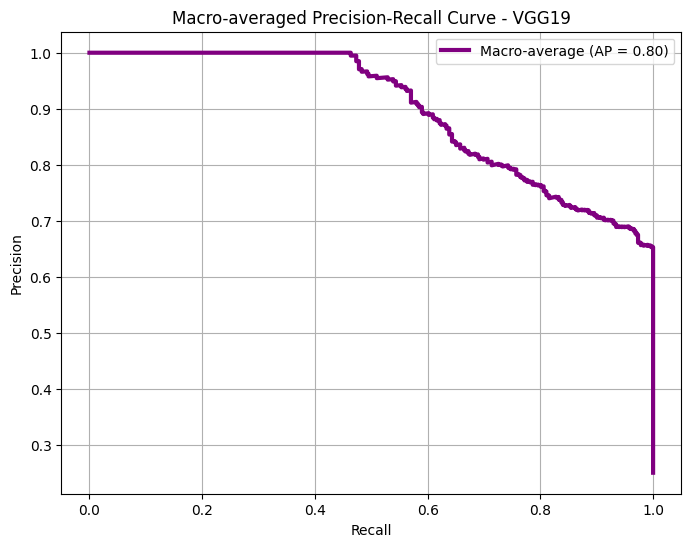

In [61]:
precision_macro, recall_macro, _ = precision_recall_curve(
    y_test_bin.ravel(), y_pred_proba.ravel()
)
ap_macro = average_precision_score(y_test_bin, y_pred_proba, average='macro')

plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro, 
         label=f'Macro-average (AP = {ap_macro:.2f})', 
         color='purple', linewidth=3)
plt.xlabel('Recall')
plt.ylabel('Precision') 
plt.title('Macro-averaged Precision-Recall Curve - VGG19')
plt.legend()
plt.grid(True)
plt.show()

Итоговая точность

In [63]:
final_accuracy = history_vgg.history['val_accuracy'][-1]
f"{final_accuracy:.4f}"

'0.7718'

Сравнение

В любом случае видно что предообученная модель лучше результат показывает

In [64]:
f"custom_model (моя) сеть: ~73% accuracy, vgg19_transfer (VGG19 Transfer Learning): {final_accuracy*100:.1f}% accuracy"

'custom_model (моя) сеть: ~73% accuracy, vgg19_transfer (VGG19 Transfer Learning): 77.2% accuracy'